<div dir="rtl" style="text-align: right;">

# تمرین ۱: سیستم تشخیص لبه تطبیقی (Adaptive Edge Detection)

در این بخش، برنامه‌ای مینویسیم که مراحل زیر را روی تصویر ورودی انجام می‌دهد:

۱. **تحلیل تصویر:** محاسبه هیستوگرام برای بررسی توزیع روشنایی و همچنین تخمین میزان نویز با استفاده از واریانس لاپلاسین (Laplacian Variance).
۲. **آستانه‌گذاری خودکار (Auto Canny):** محاسبه بهترین پارامترهای آستانه بالا و پایین برای الگوریتم Canny بر اساس میانه (Median) پیکسل‌های تصویر و ضریب $ \sigma = 0.33 $.
۳. **تفکیک و نمایش لبه‌ها:** استخراج لبه‌ها و تفکیک آن‌ها به دو دسته **لبه‌های قوی** (به رنگ قرمز) و **لبه‌های ضعیف** (به رنگ سبز).

</div>


Matplotlib is building the font cache; this may take a moment.


مقدار واریانس لاپلاسین (تخمین نویز): 500.29
آستانه پایین (Lower Threshold): 46
آستانه بالا (Upper Threshold): 91


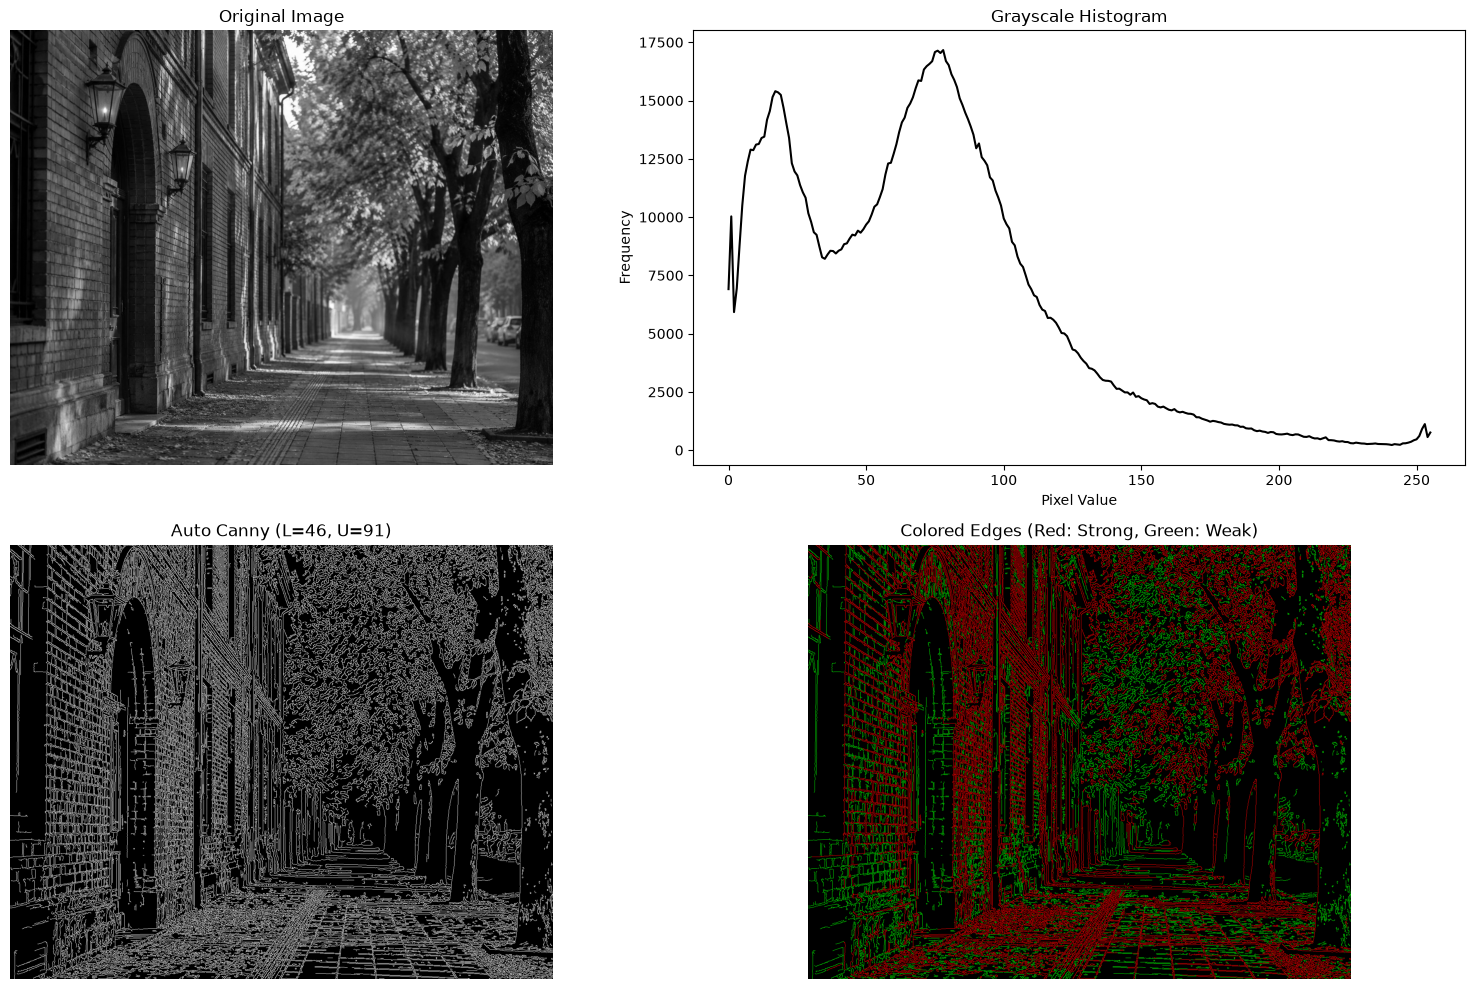

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. خواندن تصویر به صورت خاکستری
image_path = 'sample.jpg'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print(f"خطا: تصویر '{image_path}' پیدا نشد. لطفا عکس را در پوشه پروژه قرار دهید.")
else:
    # 2. محاسبه هیستوگرام
    hist = cv2.calcHist([img], [0], None, [256], [0, 256])
    
    # 3. تخمین نویز تصویر با استفاده از واریانس لاپلاسین
    laplacian_var = np.var(cv2.Laplacian(img, cv2.CV_64F))
    print(f"مقدار واریانس لاپلاسین (تخمین نویز): {laplacian_var:.2f}")
    
    # 4. محاسبه خودکار آستانه ها بر اساس میانه پیکسل ها
    sigma = 0.33
    v = np.median(img)
    lower_thresh = int(max(0, (1.0 - sigma) * v))
    upper_thresh = int(min(255, (1.0 + sigma) * v))
    print(f"آستانه پایین (Lower Threshold): {lower_thresh}")
    print(f"آستانه بالا (Upper Threshold): {upper_thresh}")
    
    # 5. تشخیص لبه ها
    # لبه های استاندارد با آستانه های تطبیقی
    all_edges = cv2.Canny(img, lower_thresh, upper_thresh)
    
    # استخراج لبه های فقط قوی (با دو برابر کردن آستانه بالا برای سخت گیری بیشتر)
    strong_edges = cv2.Canny(img, upper_thresh, upper_thresh * 2)
    
    # لبه های ضعیف (لبه هایی که در حالت عادی هستند اما قوی نیستند)
    weak_edges = cv2.bitwise_xor(all_edges, strong_edges)
    
    # 6. رنگ آمیزی لبه ها
    # ساخت یک تصویر رنگی خالی (سیاه) با ابعاد تصویر اصلی
    colored_edges = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)
    
    # لبه های قوی به رنگ قرمز (RGB: 255, 0, 0)
    colored_edges[strong_edges > 0] = [255, 0, 0]
    
    # لبه های ضعیف به رنگ سبز (RGB: 0, 255, 0)
    colored_edges[weak_edges > 0] = [0, 255, 0]
    
    # 7. نمایش نتایج
    plt.figure(figsize=(16, 10))
    
    # تصویر اصلی
    plt.subplot(2, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')
    
    # نمودار هیستوگرام
    plt.subplot(2, 2, 2)
    plt.plot(hist, color='black')
    plt.title("Grayscale Histogram")
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    
    # خروجی Canny استاندارد
    plt.subplot(2, 2, 3)
    plt.imshow(all_edges, cmap='gray')
    plt.title(f"Auto Canny (L={lower_thresh}, U={upper_thresh})")
    plt.axis('off')
    
    # خروجی لبه های رنگی
    plt.subplot(2, 2, 4)
    plt.imshow(colored_edges)
    plt.title("Colored Edges (Red: Strong, Green: Weak)")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()


<div dir="rtl" style="text-align: right;">

### مرحله ۲: اعمال فیلتر کاهنده نویز به صورت تطبیقی (Adaptive Gaussian Blur)

با توجه به اینکه تصویر دارای جزئیات و بافت زیادی است (واریانس > 300)، قبل از اعمال الگوریتم Canny باید تصویر را کمی تار (Blur) کنیم تا خطوط ریز و مزاحم حذف شوند. 
در این کد، ابعاد فیلتر Gaussian بر اساس مقدار واریانس لاپلاسین به صورت خودکار انتخاب می‌شود:
- اگر واریانس بالا باشد (بیشتر از ۳۰۰): فیلتر قوی‌تر با ابعاد $5 \times 5$
- اگر واریانس پایین باشد: فیلتر ضعیف‌تر با ابعاد $3 \times 3$

</div>


تصویر دارای بافت زیاد است. اعمال فیلتر Blur قوی تر (5x5).


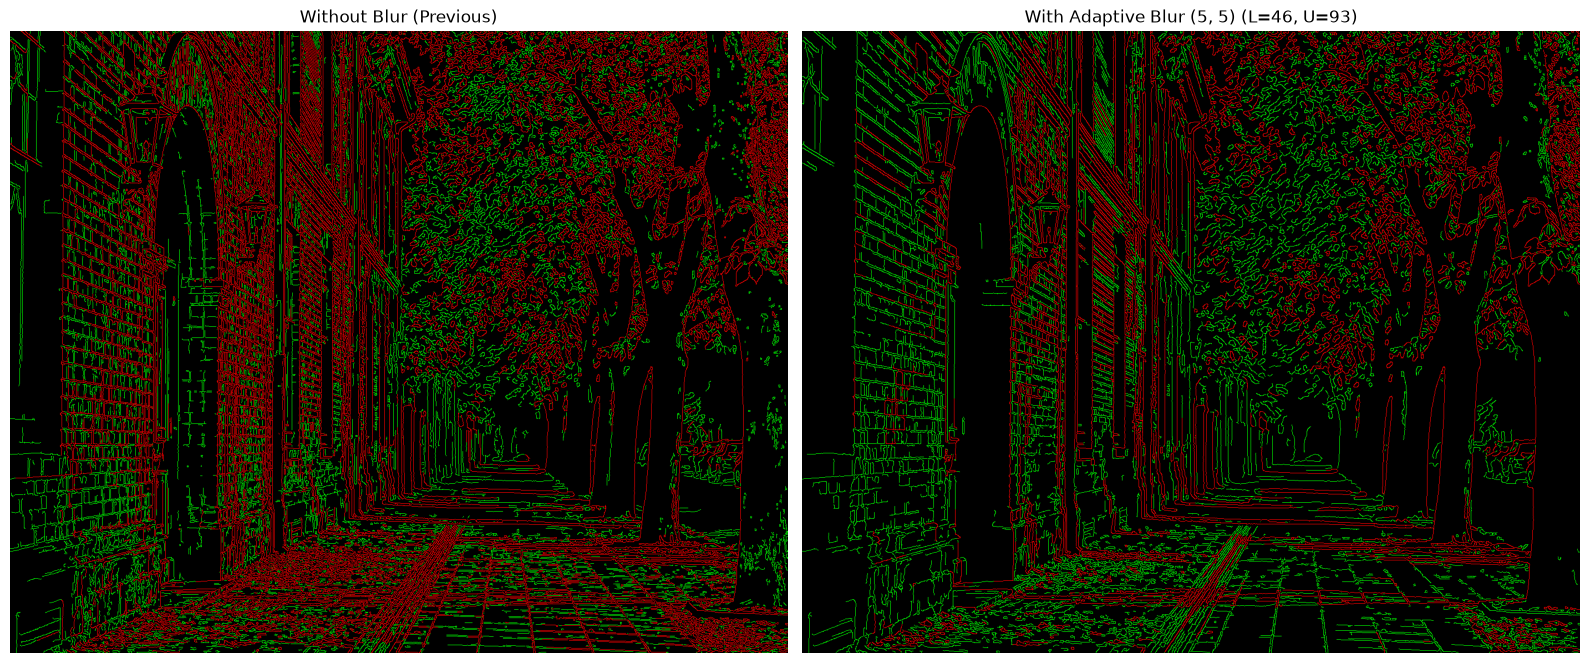

In [2]:
# 1. تعیین اندازه فیلتر بر اساس میزان نویز (واریانس لاپلاسین)
if laplacian_var > 300:
    k_size = (5, 5)
    print("تصویر دارای بافت زیاد است. اعمال فیلتر Blur قوی تر (5x5).")
else:
    k_size = (3, 3)
    print("تصویر دارای بافت کم/متوسط است. اعمال فیلتر Blur استاندارد (3x3).")

# 2. اعمال Gaussian Blur روی تصویر اصلی
blurred_img = cv2.GaussianBlur(img, k_size, 0)

# 3. محاسبه مجدد آستانه ها روی تصویر تار شده (اختیاری ولی دقیق تر)
v_blurred = np.median(blurred_img)
lower_thresh_b = int(max(0, (1.0 - sigma) * v_blurred))
upper_thresh_b = int(min(255, (1.0 + sigma) * v_blurred))

# 4. تشخیص لبه ها روی تصویر تار شده
all_edges_b = cv2.Canny(blurred_img, lower_thresh_b, upper_thresh_b)
strong_edges_b = cv2.Canny(blurred_img, upper_thresh_b, upper_thresh_b * 2)
weak_edges_b = cv2.bitwise_xor(all_edges_b, strong_edges_b)

# 5. رنگ آمیزی لبه های جدید
colored_edges_b = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)
colored_edges_b[strong_edges_b > 0] = [255, 0, 0]   # قرمز برای قوی
colored_edges_b[weak_edges_b > 0] = [0, 255, 0]     # سبز برای ضعیف

# 6. نمایش و مقایسه
plt.figure(figsize=(16, 8))

# لبه های قبلی (بدون Blur)
plt.subplot(1, 2, 1)
plt.imshow(colored_edges)
plt.title("Without Blur (Previous)")
plt.axis('off')

# لبه های جدید (با Adaptive Blur)
plt.subplot(1, 2, 2)
plt.imshow(colored_edges_b)
plt.title(f"With Adaptive Blur {k_size} (L={lower_thresh_b}, U={upper_thresh_b})")
plt.axis('off')

plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align: right;">

### مرحله ۳: استخراج خطوط ساختاری (Hough Line Transform)

اکنون که نویز تصویر را کاهش دادیم و لبه‌های اصلی را در اختیار داریم، می‌توانیم از تبدیل هاف (Hough Transform) برای استخراج خطوط مستقیم استفاده کنیم. این الگوریتم پیکسل‌های متصل در خروجی Canny را بررسی کرده و خطوط هندسی معنادار (مانند پرسپکتیو خیابان و فرم ساختمان‌ها) را پیدا می‌کند. 
در اینجا از نسخه بهینه‌تر آن یعنی `Probabilistic Hough Transform` استفاده می‌کنیم.

</div>


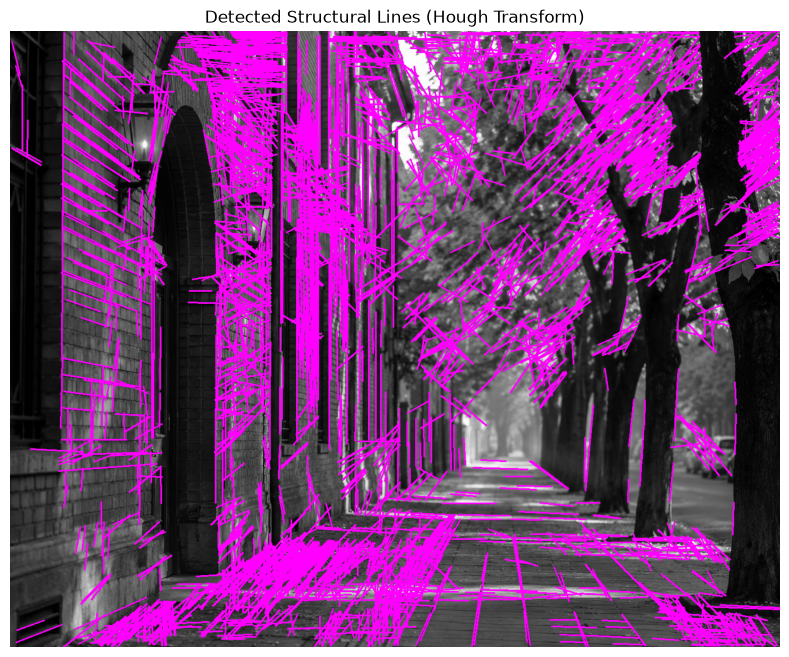

In [7]:
# 1. اعمال الگوریتم Probabilistic Hough Transform روی لبه‌های نهایی (all_edges_b)
# پارامترها برای تشخیص خطوط اصلی ساختمان و خیابان تنظیم شده‌اند
lines = cv2.HoughLinesP(
    all_edges_b, 
    rho=1,                  # دقت فاصله (۱ پیکسل)
    theta=np.pi/180,        # دقت زاویه (۱ درجه)
    threshold=50,           # حداقل تعداد پیکسل‌های لبه برای تشکیل یک خط
    minLineLength=40,       # حداقل طول خط قابل قبول
    maxLineGap=10           # حداکثر فاصله مجاز بین قطعات قطع شده یک خط
)

# 2. آماده‌سازی تصویر برای رسم خطوط رنگی (تبدیل به RGB برای نمایش در Matplotlib)
if len(img.shape) == 2: # اگر تصویر خاکستری است
    line_img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
else:                   # اگر تصویر رنگی است
    line_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 3. رسم خطوط پیدا شده
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        # رسم خطوط با رنگ بنفش (Magenta) و ضخامت ۲ پیکسل
        cv2.line(line_img, (x1, y1), (x2, y2), (255, 0, 255), 2)

# 4. نمایش تصویر نهایی
plt.figure(figsize=(12, 8))
plt.imshow(line_img)
plt.title("Detected Structural Lines (Hough Transform)")
plt.axis('off')
plt.show()
